**Load Data**

In [5]:
import pandas as pd
import matplotlib.pyplot as plt
import plotly.io as pio

df = pd.read_csv(r"c:\Users\dell\Care Load Analytics project 2\HHS_Unaccompanied_Alien_Children_Program.csv")

In [6]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,"December 21, 2025",6.0,18.0,11.0,"2,484",14.0
1,"December 18, 2025",11.0,50.0,6.0,"2,472",16.0
2,"December 17, 2025",7.0,31.0,11.0,"2,481",10.0
3,"December 16, 2025",8.0,54.0,15.0,"2,468",9.0
4,"December 15, 2025",11.0,42.0,9.0,"2,470",7.0


**Data Ingestion & Structuring**

In [7]:
print(df.columns)

Index(['Date', 'Children apprehended and placed in CBP custody*',
       'Children in CBP custody', 'Children transferred out of CBP custody',
       'Children in HHS Care', 'Children discharged from HHS Care'],
      dtype='object')


In [8]:
df.columns = df.columns.str.strip()

In [9]:
#Create a complete daily index
df['Date'] = pd.to_datetime(df['Date'])
df = df.drop_duplicates(subset='Date')
df = df.sort_values('Date')
df = df.set_index('Date').asfreq('D')
df.reset_index(inplace=True)




In [10]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care
0,2023-01-12,33.0,53.0,34.0,"6,566",436.0
1,2023-01-13,NaN,NaN,NaN,NaN,NaN
2,2023-01-14,NaN,NaN,NaN,NaN,NaN
3,2023-01-15,NaN,NaN,NaN,NaN,NaN
4,2023-01-16,NaN,NaN,NaN,NaN,NaN


In [11]:
df['Children in HHS Care'] = df['Children in HHS Care'].astype(str).str.replace(',', '')
df['Children in HHS Care'] = pd.to_numeric(df['Children in HHS Care'], errors='coerce')

In [12]:
numeric_cols = df.select_dtypes(include='number').columns
df[numeric_cols] = df[numeric_cols].interpolate(method='linear')

In [13]:
print(df.isna().sum())

Date                                               0
Children apprehended and placed in CBP custody*    0
Children in CBP custody                            0
Children transferred out of CBP custody            0
Children in HHS Care                               0
Children discharged from HHS Care                  0
dtype: int64


In [14]:
duplicate_dates = df.index[df.index.duplicated()]

print("Duplicate Dates:", duplicate_dates)
print("Total Duplicate Dates:", duplicate_dates.shape[0])

Duplicate Dates: Index([], dtype='int64')
Total Duplicate Dates: 0


In [15]:
#Transfers ≤ CBP Custody
invalid_transfers = df[df['Children transferred out of CBP custody'] > df['Children in CBP custody']]
print("Invalid Transfers Records:")
print(invalid_transfers)

Invalid Transfers Records:
          Date  Children apprehended and placed in CBP custody*  \
12  2023-01-24                                        47.000000   
13  2023-01-25                                        20.000000   
14  2023-01-26                                        20.750000   
21  2023-02-02                                        15.000000   
22  2023-02-03                                        15.333333   
..         ...                                              ...   
763 2025-02-13                                        15.000000   
764 2025-02-14                                        13.250000   
765 2025-02-15                                        11.500000   
766 2025-02-16                                         9.750000   
777 2025-02-27                                        10.000000   

     Children in CBP custody  Children transferred out of CBP custody  \
12                 42.000000                                47.000000   
13                 22.

In [16]:
df['Children in HHS Care'] = pd.to_numeric(df['Children in HHS Care'], errors='coerce')
df['Children discharged from HHS Care'] = pd.to_numeric(df['Children discharged from HHS Care'], errors='coerce')

In [17]:
#Discharges ≤ HHS Care
invalid_discharges = df[df['Children discharged from HHS Care'] > df['Children in HHS Care']]
print("Invalid Discharges Records:")
print(invalid_discharges)

Invalid Discharges Records:
Empty DataFrame
Columns: [Date, Children apprehended and placed in CBP custody*, Children in CBP custody, Children transferred out of CBP custody, Children in HHS Care, Children discharged from HHS Care]
Index: []


In [18]:
print("Invalid Transfers:", len(invalid_transfers))
print("Invalid Discharges:", len(invalid_discharges))

Invalid Transfers: 121
Invalid Discharges: 0


In [19]:
from scipy.stats import zscore

df['HHS_zscore'] = zscore(df['Children in HHS Care'])
df['Anomaly_Flag'] = abs(df['HHS_zscore']) > 3
anomalies = df[df['Anomaly_Flag'] == True]

print("Reporting Anomalies:")
print(anomalies)

Reporting Anomalies:
Empty DataFrame
Columns: [Date, Children apprehended and placed in CBP custody*, Children in CBP custody, Children transferred out of CBP custody, Children in HHS Care, Children discharged from HHS Care, HHS_zscore, Anomaly_Flag]
Index: []


In [20]:
df.head()

,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,HHS_zscore,Anomaly_Flag
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0,0.178114,False
1,2023-01-13,32.9,52.6,34.5,6621.6,415.1,0.197791,False
2,2023-01-14,32.8,52.2,35.0,6677.2,394.2,0.217467,False
3,2023-01-15,32.7,51.8,35.5,6732.8,373.3,0.237144,False
4,2023-01-16,32.6,51.4,36.0,6788.4,352.4,0.256821,False


In [21]:
print(df.dtypes)

Date                                               datetime64[ns]
Children apprehended and placed in CBP custody*           float64
Children in CBP custody                                   float64
Children transferred out of CBP custody                   float64
Children in HHS Care                                      float64
Children discharged from HHS Care                         float64
HHS_zscore                                                float64
Anomaly_Flag                                                 bool
dtype: object


In [22]:
#Total System Load
df['Total_System_Load'] = df['Children in CBP custody'] + df['Children in HHS Care']

In [23]:
#Net Daily Intake:
df['Net_Daily_Intake'] = df['Children transferred out of CBP custody'] - df['Children discharged from HHS Care']

In [24]:
#Care Load Growth Rate
df = df.sort_index()
df['Care_Load_Growth_Rate'] = df['Total_System_Load'].pct_change() * 100
df['Care_Load_Growth_Rate'] = df['Care_Load_Growth_Rate'].fillna(0)

In [25]:
#Backlog Indicator
df['Backlog_Indicator'] = df['Net_Daily_Intake'] > 0
df['Backlog_Indicator'] = df['Backlog_Indicator'].fillna(False)

In [26]:
df.head(10)


,Date,Children apprehended and placed in CBP custody*,Children in CBP custody,Children transferred out of CBP custody,Children in HHS Care,Children discharged from HHS Care,HHS_zscore,Anomaly_Flag,Total_System_Load,Net_Daily_Intake,Care_Load_Growth_Rate,Backlog_Indicator
0,2023-01-12,33.0,53.0,34.0,6566.0,436.0,0.178114,False,6619.0,-402.0,0.000000,False
1,2023-01-13,32.9,52.6,34.5,6621.6,415.1,0.197791,False,6674.2,-380.6,0.833963,False
2,2023-01-14,32.8,52.2,35.0,6677.2,394.2,0.217467,False,6729.4,-359.2,0.827065,False
3,2023-01-15,32.7,51.8,35.5,6732.8,373.3,0.237144,False,6784.6,-337.8,0.820281,False
4,2023-01-16,32.6,51.4,36.0,6788.4,352.4,0.256821,False,6839.8,-316.4,0.813607,False
5,2023-01-17,32.5,51.0,36.5,6844.0,331.5,0.276497,False,6895.0,-295.0,0.807041,False
6,2023-01-18,32.4,50.6,37.0,6899.6,310.6,0.296174,False,6950.2,-273.6,0.800580,False
7,2023-01-19,32.3,50.2,37.5,6955.2,289.7,0.315851,False,7005.4,-252.2,0.794222,False
8,2023-01-20,32.2,49.8,38.0,7010.8,268.8,0.335528,False,7060.6,-230.8,0.787964,False
9,2023-01-21,32.1,49.4,38.5,7066.4,247.9,0.355204,False,7115.8,-209.4,0.781803,False


**Trend & Temporal Analysis**

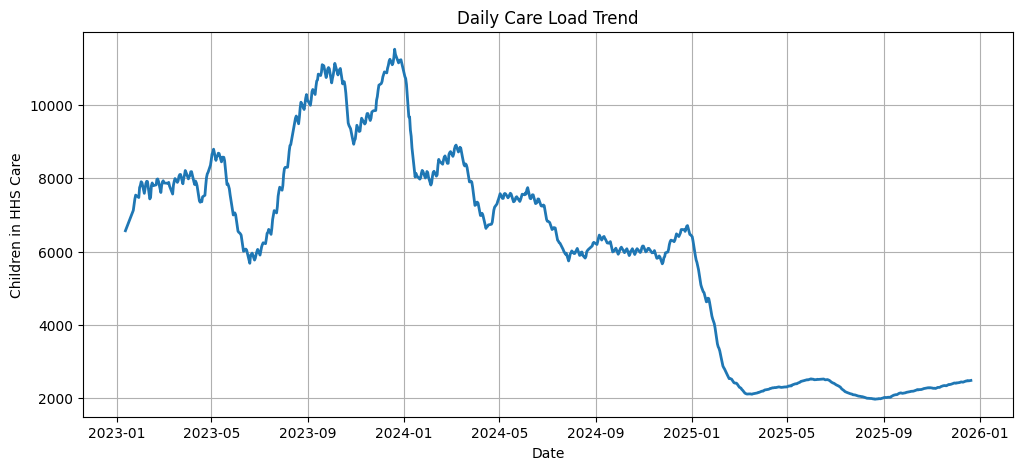

In [27]:
#Daily Care Load Trend
# Convert Date column to datetime
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by Date
df = df.sort_values('Date')

# Create Care Load column
df['Care_Load'] = df['Children in HHS Care']

# Plot Daily Care Load Trend
plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Care_Load'], linewidth=2)

plt.title("Daily Care Load Trend")
plt.xlabel("Date")
plt.ylabel("Children in HHS Care")

plt.grid()
plt.show()

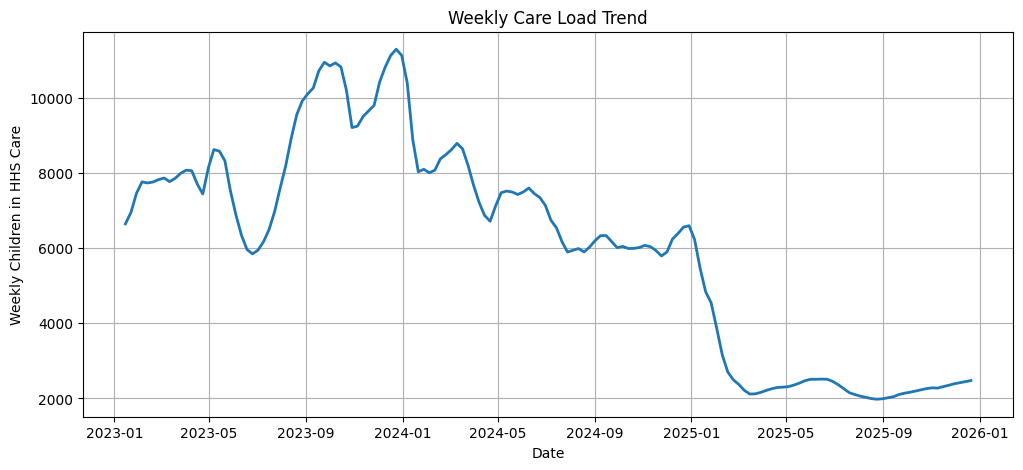

In [28]:
#Weekly Care Load Trend
df['Date'] = pd.to_datetime(df['Date'])

# Sort by Date
df = df.sort_values('Date')

# Create Care Load column
df['Care_Load'] = df['Children in HHS Care']

# Set Date as index for resampling
df_week = df.set_index('Date')

# Weekly Care Load
weekly_care_load = df_week['Care_Load'].resample('W').mean()

# Plot
plt.figure(figsize=(12,5))
plt.plot(weekly_care_load.index, weekly_care_load.values, linewidth=2)

plt.title("Weekly Care Load Trend")
plt.xlabel("Date")
plt.ylabel("Weekly Children in HHS Care")

plt.grid()
plt.show()

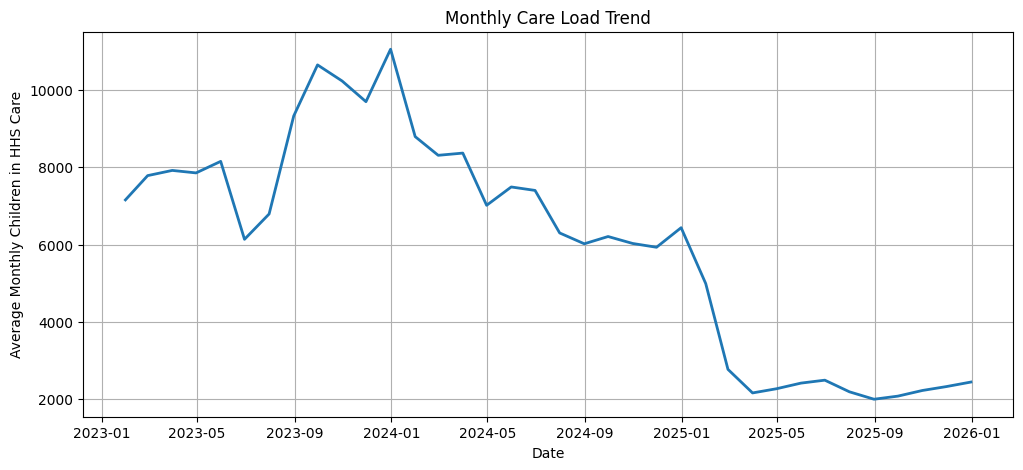

In [29]:
#monthly care Load Trend
# Convert Date column to datetime
df['Date'] = pd.to_datetime(df['Date'])

# Sort by date
df = df.sort_values('Date')

# Create Care Load column
df['Care_Load'] = df['Children in HHS Care']

# Set Date as index for resampling
df_month = df.set_index('Date')

# Monthly Care Load
monthly_care_load = df_month['Care_Load'].resample('ME').mean()

# Plot
plt.figure(figsize=(12,5))
plt.plot(monthly_care_load.index, monthly_care_load.values, linewidth=2)

plt.title("Monthly Care Load Trend")
plt.xlabel("Date")
plt.ylabel("Average Monthly Children in HHS Care")

plt.grid()
plt.show()

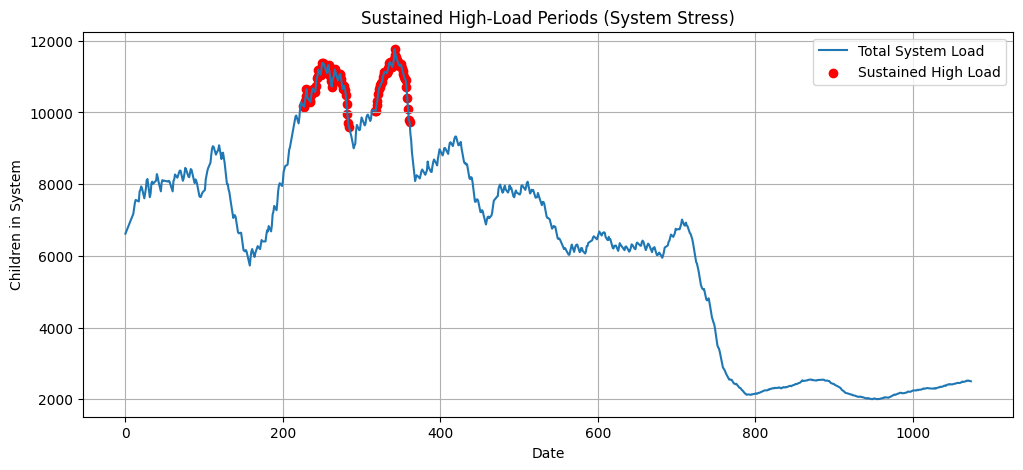

In [30]:
#• Identification of sustained high-load periods
df['Total_System_Load'] = (
    df['Children in CBP custody'] +
    df['Children in HHS Care']
)

threshold = df['Total_System_Load'].quantile(0.90)

df['High_Load'] = df['Total_System_Load'] > threshold

df['Sustained_High_Load'] = (
    df['High_Load'].rolling(window=7).sum() >= 5
)
import matplotlib.pyplot as plt

plt.figure(figsize=(12,5))

# Line plot
plt.plot(df.index, df['Total_System_Load'], label='Total System Load')

# Highlight sustained stress periods
plt.scatter(
    df.index[df['Sustained_High_Load']],
    df['Total_System_Load'][df['Sustained_High_Load']],
    color='red',
    label='Sustained High Load'
)

plt.title("Sustained High-Load Periods (System Stress)")
plt.xlabel("Date")
plt.ylabel("Children in System")
plt.legend()
plt.grid()

plt.show()

Early Period Average Care Load: 8363.611731843575
Late Period Average Care Load: 3766.078996282528


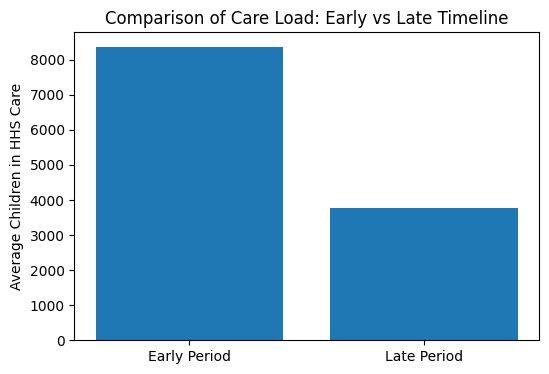

In [31]:
#• Comparison across calendar periods (early vs late timeline)
import pandas as pd
import matplotlib.pyplot as plt

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Sort data
df = df.sort_values('Date')

# Care Load
df['Care_Load'] = df['Children in HHS Care']

#Split Early vs Late Timeline
midpoint = len(df) // 2
early_period = df.iloc[:midpoint]
late_period = df.iloc[midpoint:]

#Compare Average Care Load
early_avg = early_period['Care_Load'].mean()
late_avg = late_period['Care_Load'].mean()

print("Early Period Average Care Load:", early_avg)
print("Late Period Average Care Load:", late_avg)

#Visual Comparison Chart
labels = ['Early Period', 'Late Period']
values = [early_avg, late_avg]

plt.figure(figsize=(6,4))
plt.bar(labels, values)

plt.title("Comparison of Care Load: Early vs Late Timeline")
plt.ylabel("Average Children in HHS Care")

plt.show()

**Pressure & Stress Identification**

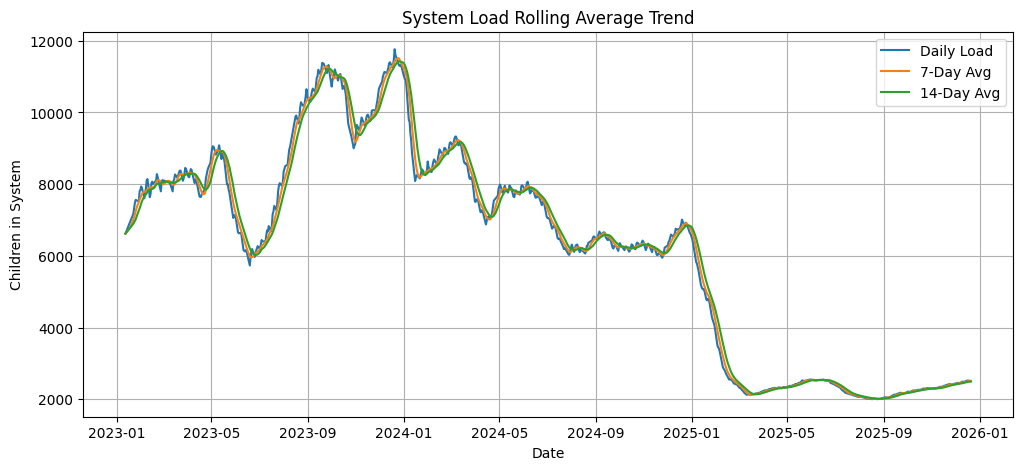

In [32]:
#Rolling averages (7-day, 14-day)
# Total System Load
df['Total_System_Load'] = (
    df['Children in CBP custody'] +
    df['Children in HHS Care']
)

# Convert Date column
df['Date'] = pd.to_datetime(df['Date'])

# Sort data
df = df.sort_values('Date')

# Rolling averages
df['Load_7Day_Avg'] = df['Total_System_Load'].rolling(window=7, min_periods=1).mean()
df['Load_14Day_Avg'] = df['Total_System_Load'].rolling(window=14, min_periods=1).mean()

plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Total_System_Load'], label='Daily Load')
plt.plot(df['Date'], df['Load_7Day_Avg'], label='7-Day Avg')
plt.plot(df['Date'], df['Load_14Day_Avg'], label='14-Day Avg')

plt.title("System Load Rolling Average Trend")
plt.xlabel("Date")
plt.ylabel("Children in System")

plt.legend()
plt.grid()
plt.show()

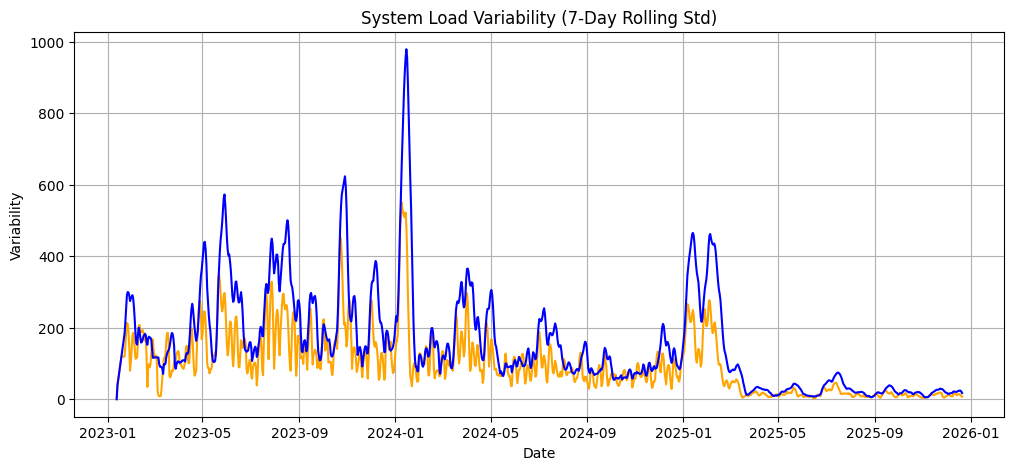

In [33]:
#Variability analysis

# Rolling standard deviation (variability)
df['Load_Variability_7Day'] = df['Total_System_Load'].rolling(7, min_periods=1).std().fillna(0)
df['Load_Variability_14Day'] = df['Total_System_Load'].rolling(14, min_periods=1).std().fillna(0)
plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Load_Variability_7Day'], label='7-Day Variability', color='orange')
plt.plot(df['Date'], df['Load_Variability_14Day'], label='14-Day Variability', color='blue')

plt.title("System Load Variability (7-Day Rolling Std)")
plt.xlabel("Date")
plt.ylabel("Variability")

plt.grid()
plt.show()

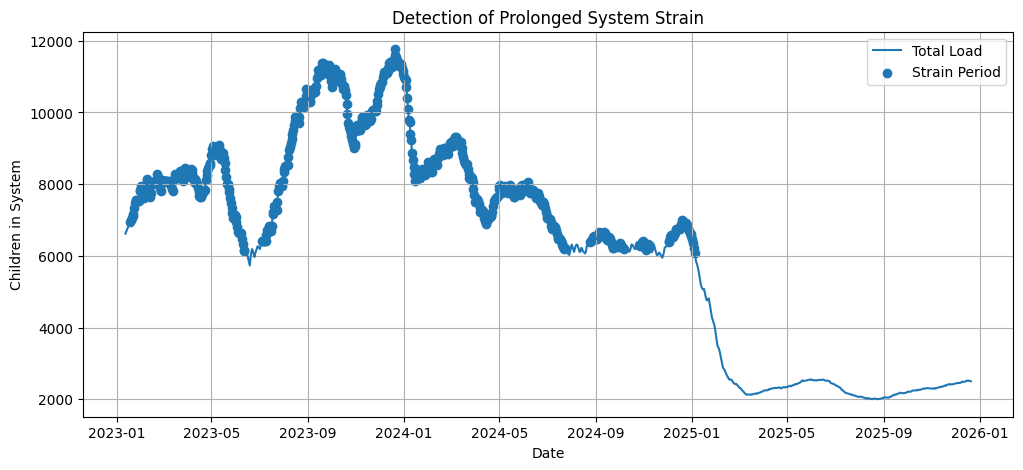

In [34]:
#Detection of Prolonged Strain Windows
# Define threshold
threshold = df['Total_System_Load'].mean()

# High load indicator
df['High_Load'] = df['Total_System_Load'] > threshold

# Sustained strain (5 of 7 days high)
df['Prolonged_Strain'] = df['High_Load'].rolling(7).sum() >= 5
plt.figure(figsize=(12,5))

plt.plot(df['Date'], df['Total_System_Load'], label='Total Load')

plt.scatter(
    df['Date'][df['Prolonged_Strain']],
    df['Total_System_Load'][df['Prolonged_Strain']],
    label='Strain Period'
)

plt.title("Detection of Prolonged System Strain")
plt.xlabel("Date")
plt.ylabel("Children in System")

plt.legend()
plt.grid()
plt.show()

In [35]:
df.reset_index().to_csv(r"C:\Users\dell\Downloads\updated HHS_Unaccompanied_Alien_Children_Program.csv", index=False)